In [1]:
import re
from pathlib import Path
import numpy as np

# Regex to match file names like A2V.asc, B5V.asc, etc. (case-insensitive)

PATTERN = re.compile(r'^[OBAFGKM][0-9]V\.asc$', re.IGNORECASE) # This is the naming convention for our spectrum files 

# Function to load spectra from a folder

def load_spectra_from_folder(folder):
    """
    Scan `folder` for files matching the pattern and load two-column ASCII files.
    Returns a dict keyed by file stem (e.g., 'A2V') with values:
      {'wl': numpy_array, 'flux': numpy_array, 'path': str(path)}
    """
    folder = Path(folder) # Convert to Path object
    spectra = {} # Initialize empty dict to hold spectra
    for f in folder.glob('*.asc'): # Iterate over all .asc files in the folder
        if not PATTERN.match(f.name): # Check if file name matches the pattern
            continue
        # Try to read two first columns, allow for header/comments
        data = np.genfromtxt(f, usecols=(0, 1), comments='#', autostrip=True)
        if data.size == 0:
            # empty or unreadable file
            print(f"Warning: no numeric data in {f}")
            continue
        # Ensure shape is (N,2)
        if data.ndim == 1:
            if data.size < 2: # Not enough data
                print(f"Warning: unexpected data shape in {f}")
                continue
            data = data.reshape(-1, 2)
        # Remove rows with NaNs
        mask = ~np.isnan(data).any(axis=1)
        data = data[mask]
        if data.size == 0: # All rows were NaN
            print(f"Warning: all rows contain NaN in {f}")
            continue
        wl = data[:, 0].astype(float) # Wavelengths
        flux = data[:, 1].astype(float) # Fluxes
        spectra[f.stem] = {'wl': wl, 'flux': flux, 'path': str(f)} # Store in dict
    return spectra # Return the spectra dictionary

## Load spectra from folder

Run the loader to find files like `A2V.asc`, `B3V.asc`, etc., and load them into `spectra`.

## Remember to change folder = '(THE LOCATION OF STARS FOLDER)'

In [ ]:
# Set the folder and load spectra (change path if needed)
folder = r"C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace" # REPLACE WITH YOUR FILE STARS PATH!
spectra = load_spectra_from_folder(folder) # Load spectra
print(f"Loaded {len(spectra)} spectra from {folder}") # Print number of loaded spectra
for name, d in sorted(spectra.items()): # Print summary of loaded spectra
    print(name, d['wl'].size, 'points —', d['path']) # Print the name, number of points, and file path

Loaded 18 spectra from C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace
A2V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\A2V.asc
A6V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\A6V.asc
A9V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\A9V.asc
B1V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\B1V.asc
B6V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\B6V.asc
F0V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\F0V.asc
F5V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\F5V.asc
F9V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\F9V.asc
G2V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\G2V.asc
G6V 2799 points — C:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\G6V.asc
G9V 2799 points — C:\Users\Bruger\D

In [3]:
# Save all spectra to a compressed .npz file in a safe two-step way
to_save = {} # Prepare dict for saving
for name, d in spectra.items(): # Iterate over loaded spectra
    to_save[f"{name}_wl"] = d['wl'] # Save wavelength array
    to_save[f"{name}_flux"] = d['flux'] # Save flux array
np.savez_compressed('spectra_archive.npz', **to_save) # Save to .npz file

# Example of loading a .npz file:
data = np.load('spectra_archive.npz') # Load from .npz file
#wl = data['A2V_wl'] ; flux = data['A2V_flux']
#print(wl, flux)

print(to_save)

{'A2V_wl': array([3510.    , 3511.3999, 3512.8   , ..., 7424.3999, 7425.7998,
       7427.2002], shape=(2799,)), 'A2V_flux': array([1.156e-07, 1.161e-07, 1.170e-07, ..., 7.158e-08, 6.973e-08,
       6.854e-08], shape=(2799,)), 'A6V_wl': array([3510.    , 3511.3999, 3512.8   , ..., 7424.3999, 7425.7998,
       7427.2002], shape=(2799,)), 'A6V_flux': array([6.438e-08, 6.277e-08, 6.377e-08, ..., 2.712e-08, 2.713e-08,
       2.693e-08], shape=(2799,)), 'A9V_wl': array([3510.    , 3511.3999, 3512.8   , ..., 7424.3999, 7425.7998,
       7427.2002], shape=(2799,)), 'A9V_flux': array([3.520e-08, 3.506e-08, 3.492e-08, ..., 2.471e-08, 2.406e-08,
       2.465e-08], shape=(2799,)), 'B1V_wl': array([3510.    , 3511.3999, 3512.8   , ..., 7424.3999, 7425.7998,
       7427.2002], shape=(2799,)), 'B1V_flux': array([1.741e-05, 1.722e-05, 1.732e-05, ..., 1.926e-06, 1.855e-06,
       1.819e-06], shape=(2799,)), 'B6V_wl': array([3510.    , 3511.3999, 3512.8   , ..., 7424.3999, 7425.7998,
       7427.2002],

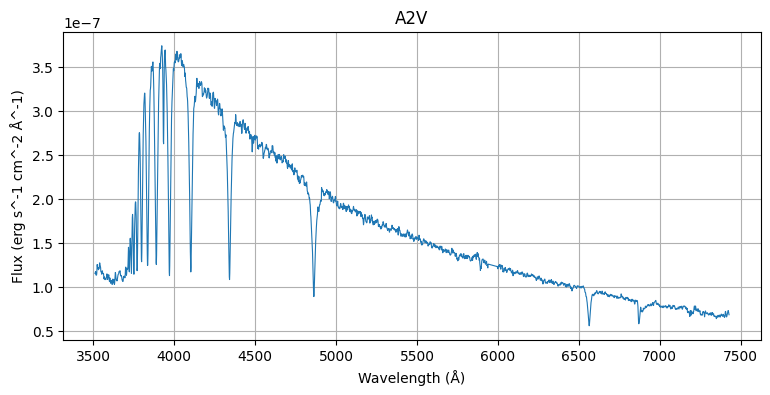

In [4]:
# Quick plot of the first spectrum (matplotlib)
import matplotlib.pyplot as plt # Import matplotlib for plotting
if len(spectra) == 0: # Check if any spectra were loaded
    print('No spectra loaded — check the folder/path and filename pattern') # Print warning if no spectra
else: # If spectra were loaded
    name = next(iter(spectra)) # Get the first spectrum name
    wl = spectra[name]['wl'] # Wavelength array
    flux = spectra[name]['flux'] # Flux array
    plt.figure(figsize=(9,4)) # Create a new figure
    plt.plot(wl, flux, lw=0.8) # Plot the spectrum
    plt.xlabel('Wavelength (Å)') # Label x-axis
    plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)') # Label y-axis
    plt.title(name) # Set title to spectrum name
    plt.grid(True) # Enable grid
    plt.show() # Show the plot

In [ ]:
# Optional: interactive dropdown to choose a spectrum (requires ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import matplotlib.pyplot as plt

    if len(spectra) == 0: # Check if any spectra were loaded
        print('No spectra to select.') # Print warning if no spectra
    else:
        dropdown = widgets.Dropdown(options=sorted(spectra.keys()), description='Spectrum:') # Create dropdown widget
        out = widgets.Output() # Output widget for displaying plots

        def on_change(change): # Callback function for dropdown change
            if change['type'] == 'change' and change['name'] == 'value': # Check if value changed
                with out: # Use output widget
                    clear_output(wait=True) # Clear previous output
                    n = change['new'] # Get new selected spectrum name
                    wl = spectra[n]['wl'] # Wavelength array
                    flux = spectra[n]['flux'] # Flux array
                    plt.figure(figsize=(9,4)) # Create a new figure
                    plt.plot(wl, flux, lw=0.8) # Plot the spectrum
                    plt.xlabel('Wavelength (Å)') # Label x-axis
                    plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)') # Label y-axis
                    plt.title(n) # Set title to spectrum name
                    plt.grid(True) # Enable grid
                    plt.show() # Show the plot

        dropdown.observe(on_change) # Attach callback to dropdown
        display(dropdown, out) # Display the dropdown and output widgets

except Exception as e: # Catch any exceptions (e.g., ipywidgets not installed)
    print('To enable interactive selection install ipywidgets:') # Print instructions for installing ipywidgets
    print('pip install ipywidgets') # Installation command
    print('Then enable notebook extension if needed (classic notebook). Error:', e) # Print error message

Dropdown(description='Spectrum:', options=('A2V', 'A6V', 'A9V', 'B1V', 'B6V', 'F0V', 'F5V', 'F9V', 'G2V', 'G6V…

Output()

# If spectra_archive.npz already exists the code WILL hang. If you change anything in the .asc files, you need to delete the .npz archive and run this code again